# Chapter 1 Foundations

## Functions

### NumPy

In [ ]:
import numpy as np

print("Python list operations:")


a = [1, 2, 3]


b = [4, 5, 6]


print("a+b:", a + b)
try:


    print(a * b)


except TypeError:

    print("a*b has no meaning for Python lists")
print()



print("numpy array operations:")


a = np.array([1, 2, 3])


b = np.array([4, 5, 6])


print("a+b:", a + b)


print("a*b:", a * b)

Python list operations:
a+b: [1, 2, 3, 4, 5, 6]
a*b has no meaning for Python lists

numpy array operations:
a+b: [5 7 9]
a*b: [ 4 10 18]


In [2]:
a = np.array([[1, 2], [3, 4]])
print("a:")
print(a)
print("a.sum(axis=0):", a.sum(axis=0))
print("a.sum(axis=1):", a.sum(axis=1))

a:
[[1 2]
 [3 4]]
a.sum(axis=0): [4 6]
a.sum(axis=1): [3 7]


In [3]:
a = np.array([[1, 2, 3], [4, 5, 6]])
b = np.array([10, 20, 30])
print("a+b:\n", a + b)

a+b:
 [[11 22 33]
 [14 25 36]]


### Type-checked functions

In [4]:
# def __init__(self, layers: List[Layer], loss: Loss, learning_rate: float = 0.01) -> None:

# def operation(x1, x2):



# def operation(x1: ndarray, x2: ndarray) -> ndarray:

### Basic functions in NumPy

In [5]:
from numpy import ndarray


def square(x: ndarray) -> ndarray:
    """
    Square each element in the input ndarray.
    """
    return np.power(x, 2)


def leaky_relu(x: ndarray) -> ndarray:
    """
    Apply "Leaky ReLU" function to each element in ndarray.
    """
    return np.maximum(0.2 * x, x)

Text(0, 0.5, 'output')

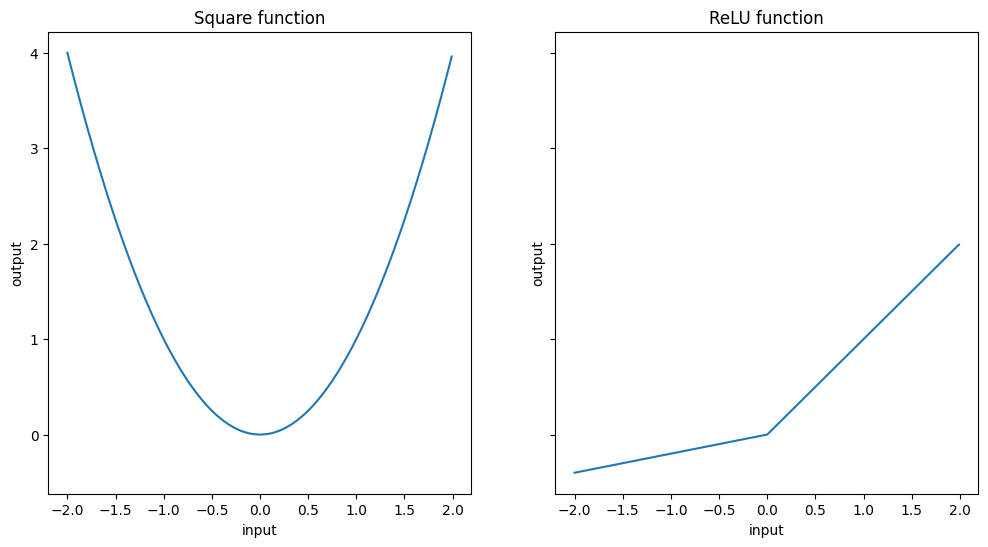

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, sharey=True, figsize=(12, 6))  # 2 Rows, 1 Col
input_range = np.arange(-2, 2, 0.01)

ax[0].plot(input_range, square(input_range))
ax[0].set_title("Square function")
ax[0].set_xlabel("input")
ax[0].set_ylabel("output")

ax[1].plot(input_range, leaky_relu(input_range))
ax[1].set_title("ReLU function")
ax[1].set_xlabel("input")
ax[1].set_ylabel("output")

## Derivatives

In [7]:
from typing import Callable


def deriv(
    func: Callable[[ndarray], ndarray], input_: ndarray, delta: float = 0.001
) -> ndarray:
    """
    Evaluates the derivative of a function "func" at every element in the "input_" array.
    """
    return (func(input_ + delta) - func(input_ - delta)) / (2 * delta)

## Nested Functions

In [8]:
from typing import List

# A Function takes in an ndarray as an argument and produces an ndarray
Array_Function = Callable[[ndarray], ndarray]

# A Chain is a list of functions
Chain = List[Array_Function]

In [9]:
def chain_length_2(chain: Chain, x: ndarray) -> ndarray:
    """
    Evaluates two functions in a row, in a "Chain".
    """
    assert len(chain) == 2, "Length of input 'chain' should be 2"

    f1 = chain[0]
    f2 = chain[1]

    return f2(f1(x))

## The Chain Rule

In [10]:
def sigmoid(x: ndarray) -> ndarray:
    """
    Apply the sigmoid function to each element in the input ndarray.
    """
    return 1 / (1 + np.exp(-x))

In [11]:
def chain_deriv_2(chain: Chain, input_range: ndarray) -> ndarray:
    """
    Uses the chain rule to compute the derivative of two nested functions:
    (f2(f1(x)))' = f2'(f1(x)) * f1'(x)
    """

    assert len(chain) == 2, "This function requires 'Chain' objects of length 2"
    assert (
        input_range.ndim == 1
    ), "Function requires a 1 dimensional ndarray as input_range"

    f1 = chain[0]
    f2 = chain[1]

    # f1(x)
    f1_of_x = f1(input_range)

    # (df1/du)(x)
    df1dx = deriv(f1, input_range)

    # (df2/du)(f1(x))
    df2du = deriv(f2, f1_of_x)

    # Multiplying these quantities together at each point
    return df1dx * df2du

In [12]:
def plot_chain(ax, chain: Chain, input_range: ndarray) -> None:
    """
    Plots a chain function - a function made up of
    multiple consecutive ndarray -> ndarray mappings -
    Across the input_range

    ax: matplotlib Subplot for plotting
    """

    assert (
        input_range.ndim == 1
    ), "Function requires a 1 dimensional ndarray as input_range"

    output_range = chain_length_2(chain, input_range)
    ax.plot(input_range, output_range)

In [13]:
def plot_chain_deriv(ax, chain: Chain, input_range: ndarray) -> ndarray:
    """
    Use the chain rule to plot the derivative of a function consisting of two nested functions.

    ax: matplotlib Subplot for plotting
    """

    output_range = chain_deriv_2(chain, input_range)
    ax.plot(input_range, output_range)

Text(0.5, 1.0, 'Function and derivative for\n$f(x) = square(sigmoid(x))$')

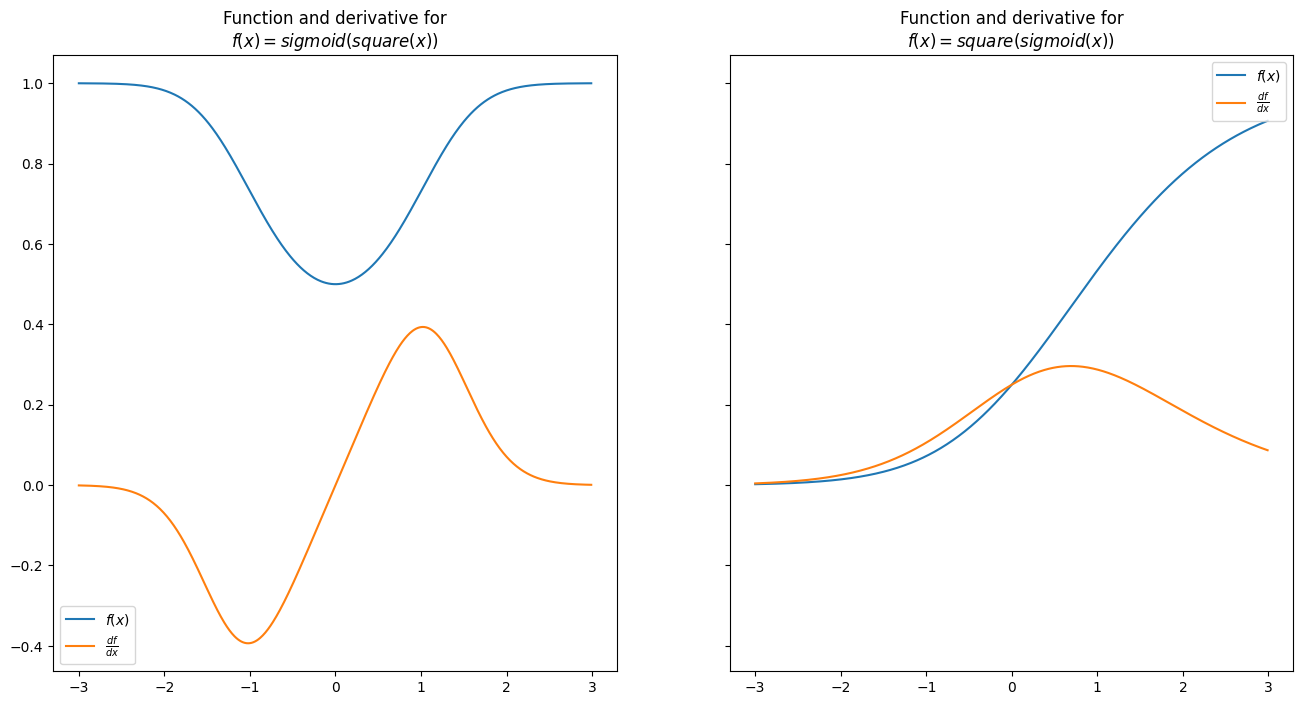

In [14]:
fig, ax = plt.subplots(1, 2, sharey=True, figsize=(16, 8))  # 2 Rows, 1 Col

PLOT_RANGE = np.arange(-3, 3, 0.01)

chain_1 = [square, sigmoid]
chain_2 = [sigmoid, square]

plot_chain(ax[0], chain_1, PLOT_RANGE)
plot_chain_deriv(ax[0], chain_1, PLOT_RANGE)
ax[0].legend(["$f(x)$", "$\\frac{df}{dx}$"])
ax[0].set_title("Function and derivative for\n$f(x) = sigmoid(square(x))$")

plot_chain(ax[1], chain_2, PLOT_RANGE)
plot_chain_deriv(ax[1], chain_2, PLOT_RANGE)
ax[1].legend(["$f(x)$", "$\\frac{df}{dx}$"])
ax[1].set_title("Function and derivative for\n$f(x) = square(sigmoid(x))$")

## A Slightly Longer Example

In [15]:
def chain_deriv_3(chain: Chain, input_range: ndarray) -> ndarray:
    """
    Users the chain rule to compute the derivative of three nested functions:
    (f3(f2(f1)))' = f3'(f2(f1(x))) * f2'(f1(x)) * f1'(x)
    """

    assert len(chain) == 3, "This function requires 'Chain' objects to have length 3"

    f1 = chain[0]
    f2 = chain[1]
    f3 = chain[2]

    # f1(x)
    f1_of_x = f1(input_range)

    # f2(f1(x))
    f2_of_x = f2(f1_of_x)

    # df3du
    df3du = deriv(f3, f2_of_x)

    # df2du
    df2du = deriv(f2, f1_of_x)

    # df1dx
    df1dx = deriv(f1, input_range)

    # Multiplying these quantities together at each point
    return df1dx * df2du * df3du

In [16]:
def chain_length_3(chain: Chain, x: ndarray) -> ndarray:
    """
    Evaluates three functions in a row, in a "Chain".
    """
    assert len(chain) == 3, "Length of input 'chain' should be 3"

    f1 = chain[0]
    f2 = chain[1]
    f3 = chain[2]

    return f3(f2(f1(x)))

In [17]:
def plot_chain(ax, chain: Chain, input_range: ndarray) -> None:
    """
    Plots a chain function - a function made up of
    multiple consecutive ndarray -> ndarray mappings -
    Across the input_range

    ax: matplotlib Subplot for plotting
    """

    assert (
        input_range.ndim == 1
    ), "Function requires a 1 dimensional ndarray as input_range"

    if len(chain) == 2:
        output_range = chain_length_2(chain, input_range)
    elif len(chain) == 3:
        output_range = chain_length_3(chain, input_range)
    ax.plot(input_range, output_range)

In [18]:
def plot_chain_deriv(ax, chain: Chain, input_range: ndarray) -> ndarray:
    """
    Use the chain rule to plot the derivative of a function consisting of nested functions.

    ax: matplotlib Subplot for plotting
    """

    if len(chain) == 2:
        output_range = chain_deriv_2(chain, input_range)
    elif len(chain) == 3:
        output_range = chain_deriv_3(chain, input_range)
    ax.plot(input_range, output_range)

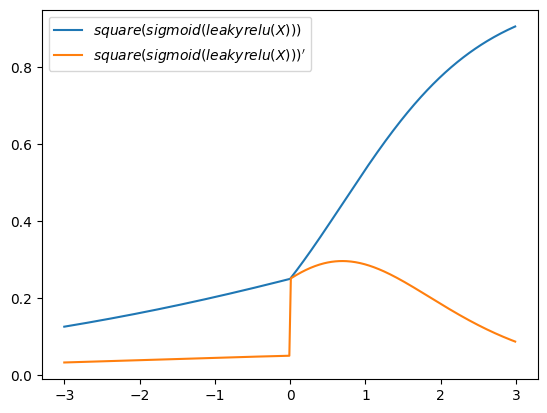

In [19]:
fig, ax = plt.subplots()

PLOT_RANGE = np.arange(-3, 3, 0.01)

plot_chain(ax, [leaky_relu, sigmoid, square], PLOT_RANGE)
plot_chain_deriv(ax, [leaky_relu, sigmoid, square], PLOT_RANGE)
ax.legend(["$square(sigmoid(leakyrelu(X)))$", "$square(sigmoid(leakyrelu(X)))'$"])

## Functions with Multiple Inputs

In [20]:
def multiple_inputs_add(x: ndarray, y: ndarray, sigma: Array_Function) -> float:
    """
    Function with multiple inputs and addition, forward pass.
    """
    assert x.shape == y.shape

    a = x + y
    return sigma(a)

## Derivatives of Functions with Multiple Inputs

In [21]:
def multiple_inputs_add_backward(
    x: ndarray, y: ndarray, sigma: Array_Function
) -> float:
    """
    Computes the derivative of this simple function with respect to
    both inputs.
    """
    # Compute "forward pass"
    a = x + y

    # Compute derivatives
    dsda = deriv(sigma, a)

    dadx, dady = 1, 1

    return dsda * dadx, dsda * dady

## Functions with Multiple Vector Inputs

## Creating New Features from Existing Features

In [22]:
def matmul_forward(X: ndarray, W: ndarray) -> ndarray:
    """
    Computes the forward pass of a matrix multiplication.
    """

    assert (
        X.shape[1] == W.shape[0]
    ), """For matrix multiplication, the number of columns in the first array should
    match the number of rows in the second; instead the number of columns in the
    first array is {0} and the number of rows in the second array is {1}.""".format(
        X.shape[1], W.shape[0]
    )

    # matrix multiplication
    N = np.dot(X, W)

    return N

## Derivatives of Functions with Multiple Vector Inputs

In [23]:
def matmul_backward_first(X: ndarray, W: ndarray) -> ndarray:
    """
    Computes the backward pass of a matrix multiplication with respect to the
    first argument.
    """

    # backward pass
    dNdX = np.transpose(W, (1, 0))

    return dNdX

## Vector Functions and Their Derivatives: One Step Further

In [24]:
def matrix_forward_extra(X: ndarray, W: ndarray, sigma: Array_Function) -> ndarray:
    """
    Computes the forward pass of a function involving matrix multiplication,
    one extra function.
    """
    assert X.shape[1] == W.shape[0]

    # matrix multiplication
    N = np.dot(X, W)

    # feeding the output of the matrix multiplication through sigma
    S = sigma(N)

    return S

### Vector Functions and Their Derivatives: The Backward Pass

In [25]:
def matrix_function_backward_1(
    X: ndarray, W: ndarray, sigma: Array_Function
) -> ndarray:
    """
    Computes the derivative of our matrix function with respect to
    the first element.
    """
    assert X.shape[1] == W.shape[0]

    # matrix multiplication
    N = np.dot(X, W)

    # feeding the output of the matrix multiplication through sigma
    S = sigma(N)

    # backward calculation
    dSdN = deriv(sigma, N)

    # dNdX
    dNdX = np.transpose(W, (1, 0))

    # multiply them together; since dNdX is 1x1 here, order doesn't matter
    return np.dot(dSdN, dNdX)

In [26]:
np.random.seed(190203)

X = np.random.randn(1, 3)
W = np.random.randn(3, 1)

print(X)
print(W)

print(matrix_function_backward_1(X, W, sigmoid))

[[ 0.47231121  0.61514271 -1.72622715]]
[[ 0.92819676]
 [-0.60754888]
 [-1.22136052]]
[[ 0.08516695 -0.05574581 -0.11206627]]


In [27]:
def forward_test(ind1, ind2, inc):

    X1 = X.copy()
    X1[ind1, ind2] = X[ind1, ind2] + inc

    return matrix_forward_extra(X1, W, sigmoid)

In [28]:
(np.round(forward_test(0, 2, 0.01) - forward_test(0, 2, 0), 4)) / 0.01

array([[-0.11]])

In [29]:
np.round(matrix_function_backward_1(X, W, sigmoid)[0, 2], 2)

np.float64(-0.11)

## Computational Graph with Two 2D Matrix Inputs

In [30]:
def matrix_function_forward_sum(X: ndarray, W: ndarray, sigma: Array_Function) -> float:
    """
    Computing the result of the forward pass of this function with
    input ndarrays X and W and function sigma.
    """
    assert X.shape[1] == W.shape[0]

    # matrix multiplication
    N = np.dot(X, W)

    # feeding the output of the matrix multiplication throgh sigma
    S = sigma(N)

    # sum all the elements
    L = np.sum(S)

    return L

## The Fun Part: The Backward Pass

In [31]:
def matrix_function_backward_sum_1(
    X: ndarray, W: ndarray, sigma: Array_Function
) -> ndarray:
    """
    Compute derivative of matrix function with a sum with respect to the
    first matrix input.
    """
    assert X.shape[1] == W.shape[0]

    # matrix multiplication
    N = np.dot(X, W)

    # feeding the output of the matrix multiplication through sigma
    S = sigma(N)

    # sum all the elements
    L = np.sum(S)

    # note: I'll refer to the derivatives by their quantities here,
    # unlike the math, where we referred to their function names

    # dLdS - just 1s
    dLdS = np.ones_like(S)

    # dSdN
    dSdN = deriv(sigma, N)

    # dLdN
    dLdN = dLdS * dSdN

    # dNdX
    dNdX = np.transpose(W, (1, 0))

    # dLdX
    dLdX = np.dot(dLdN, dNdX)

    return dLdX

In [32]:
np.random.seed(190204)
X = np.random.randn(3, 3)
W = np.random.randn(3, 2)

print("X:")
print(X)

print("L:")
print(round(matrix_function_forward_sum(X, W, sigmoid), 4))
print()
print("dLdX:")
print(matrix_function_backward_sum_1(X, W, sigmoid))

X:
[[-1.57752816 -0.6664228   0.63910406]
 [-0.56152218  0.73729959 -1.42307821]
 [-1.44348429 -0.39128029  0.1539322 ]]
L:
2.3755

dLdX:
[[ 0.2488887  -0.37478057  0.01121962]
 [ 0.12604152 -0.27807404 -0.13945837]
 [ 0.22992798 -0.36623443 -0.02252592]]


In [33]:
X1 = X.copy()
X1[0, 0] += 0.001

print(
    round(
        (
            matrix_function_forward_sum(X1, W, sigmoid)
            - matrix_function_forward_sum(X, W, sigmoid)
        )
        / 0.001,
        4,
    )
)

0.2489


### Describing these gradients visually

In [34]:
print("X:")
print(X)

X:
[[-1.57752816 -0.6664228   0.63910406]
 [-0.56152218  0.73729959 -1.42307821]
 [-1.44348429 -0.39128029  0.1539322 ]]


In [35]:
x11s = np.arange(X[0][0] - 1, X[0][0] + 1, 0.01)

Ls = []
for x11 in x11s:
    X_new = X.copy()
    X_new[0][0] = x11
    Ls.append(matrix_function_forward_sum(X_new, W, sigmoid))

Text(0, 0.5, '$L$')

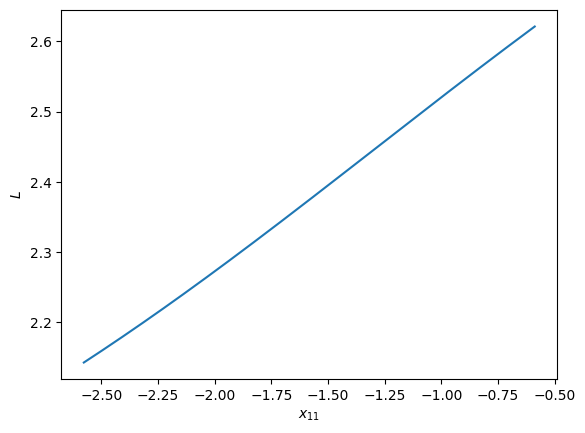

In [36]:
plt.plot(x11s, Ls)
plt.xlabel("$x_{11}$")
plt.ylabel("$L$")